# Impacting oscillator

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bernardorivas/hybrid_boxmap/blob/main/notebooks/impacting_oscillator.ipynb)

The system is given by

$$\dot x=v,\qquad \dot v=x-x^3+\varepsilon(\beta-x^2)\,v,\qquad x\leq w,$$

with guard and reset

$$G=\{(w,v): v\geq 0\},\qquad r(w,v)=(w,-cv),$$

where $\varepsilon=1$, $\beta=0.76$, $w=0.8$, and $c=0.7$.

In [5]:
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/hybrid_boxmap"):
        !git clone -q --depth 1 https://github.com/bernardorivas/hybrid_boxmap.git /content/hybrid_boxmap
        !which dot > /dev/null || (apt-get -qq update && apt-get -qq install -y graphviz) > /dev/null
    os.chdir("/content/hybrid_boxmap")
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

## Phase portrait

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from hybrid_dynamics.examples.paper_examples import paper_problem

problem = paper_problem("impact-vdp-duffing-beta076")

fig, ax = plt.subplots(figsize=(5, 4))
for state in [(-1.5, 0.0), (0.3, 0.0), (-0.5, 1.5), (0.7, 0.05), (0.75, -0.1), (-1.9, 1.9), (0.0, 0.05)]:
    trajectory = problem.system.simulate(np.array(state, float), (0.0, 40.0), max_jumps=200, max_step=0.02)
    color = None
    for segment in trajectory.segments:
        line, = ax.plot(*np.asarray(segment.state_values).T, lw=0.8, color=color)
        color = line.get_color()
ax.plot([0.8, 0.8], [0, 1.95], color="k", lw=2.5)  # guard
ax.set(xlim=(-1.95, 0.82), ylim=(-2.35, 1.95), xlabel="x", ylabel="v")
plt.show()

## Morse sets

Stored computation: $\tau=0.5$ on a $2^{11}\times2^{11}$ grid of $R=[-1.95,0.8]\times[-2.35,1.95]$.

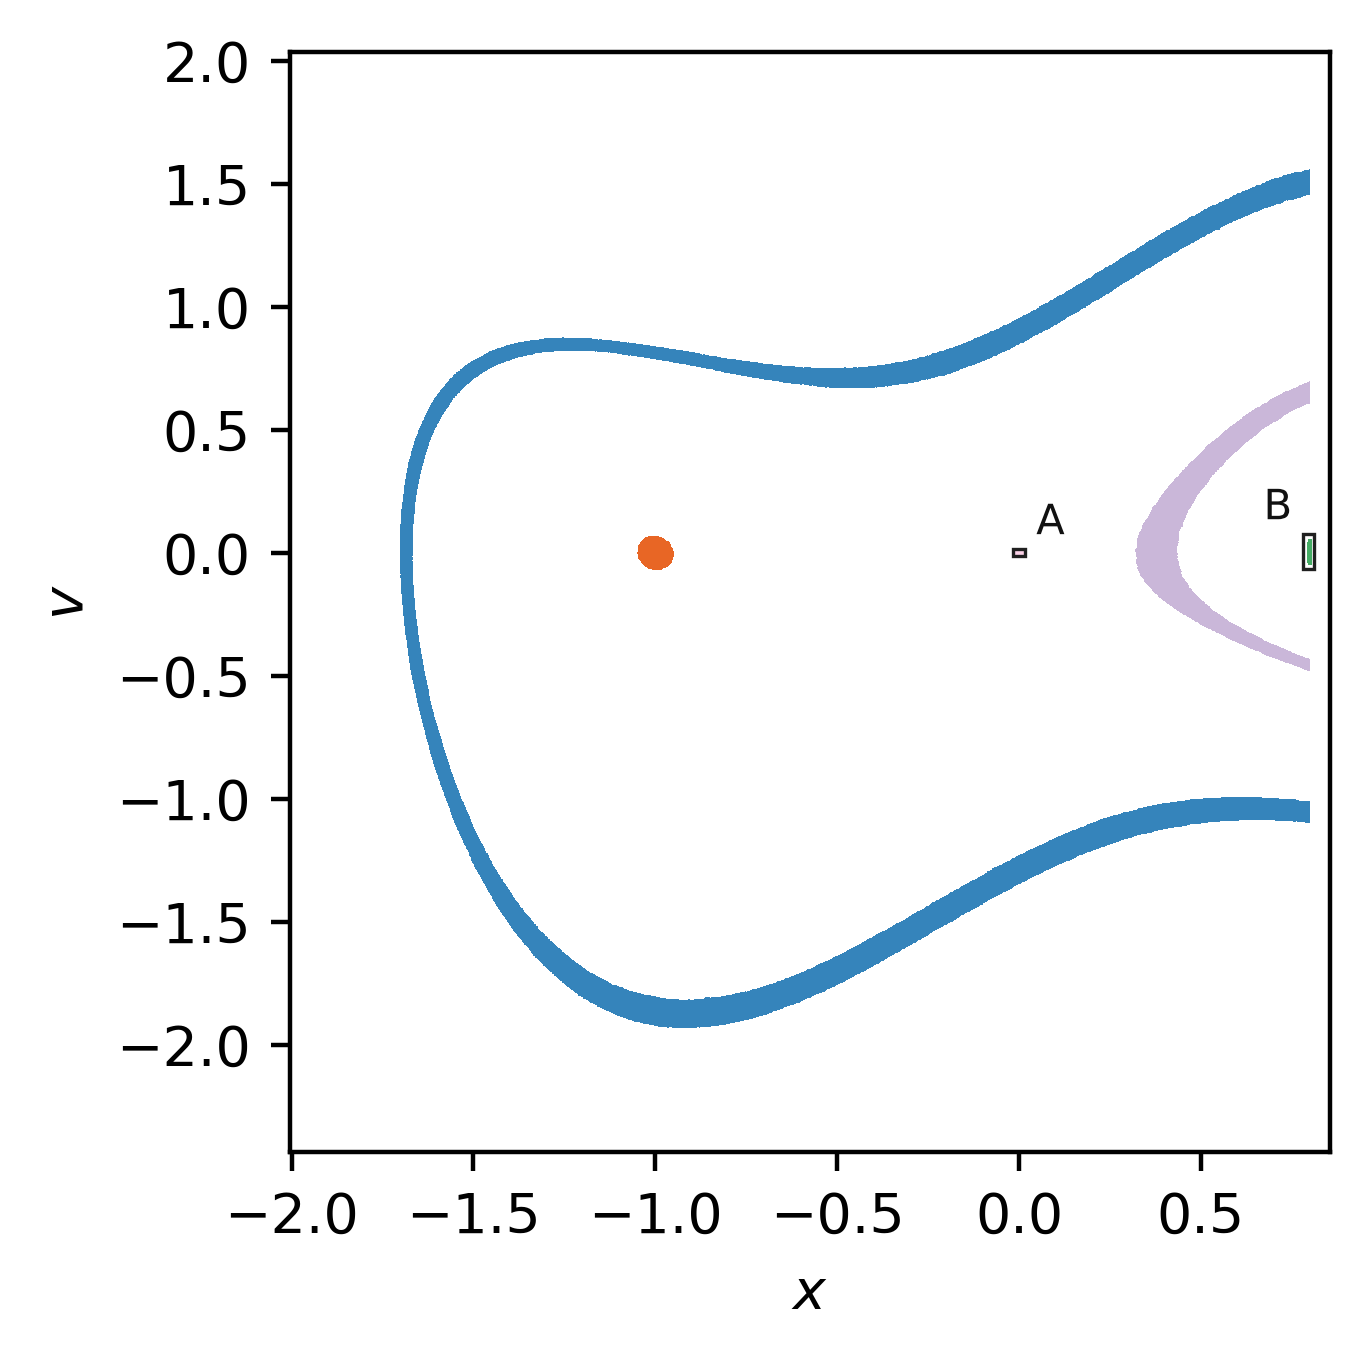

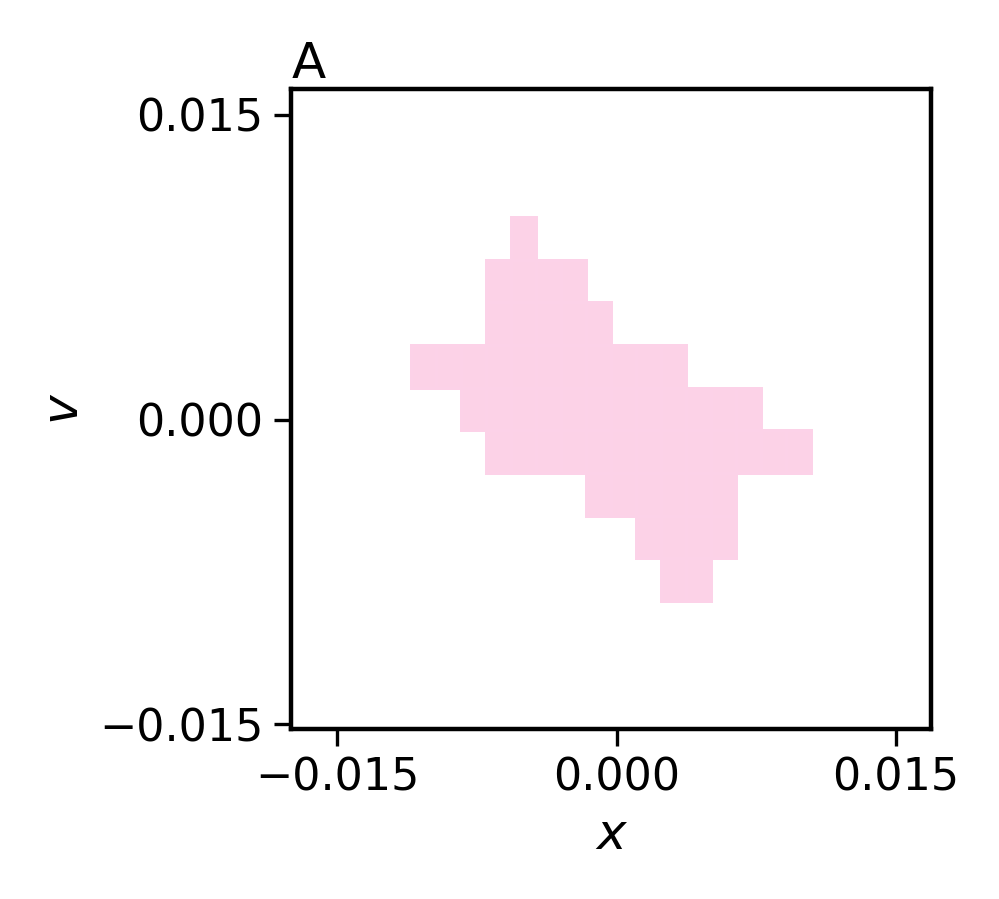

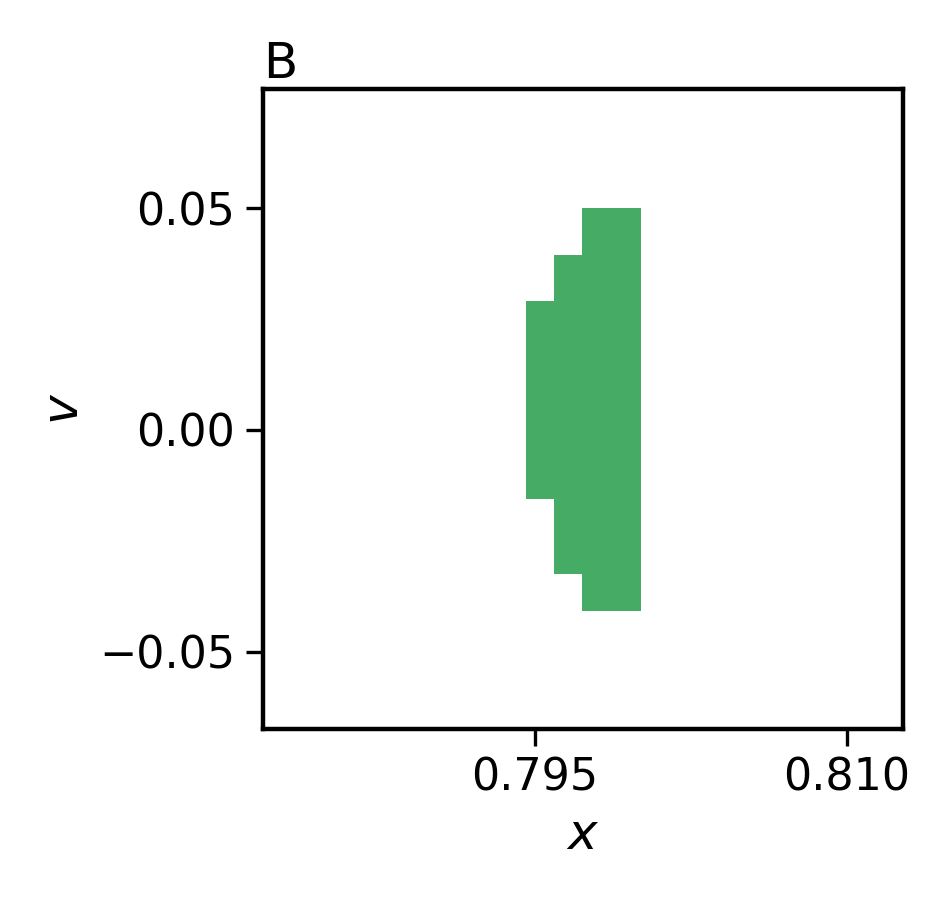

In [7]:
from pathlib import Path
from IPython.display import Image, display
from demo.replot_paper import replot

record = Path("figures/paper/paper-impact-vdp-duffing-beta076-tau050-level7-base2048-corners-gap-refined.json")
replot(record, output_dir=Path("output"), update_json=False)
stem = "output/paper-impact-vdp-duffing-beta076-tau050-level7-base2048-corners-gap-refined"

for panel in ["nontrivial-base", "nontrivial-zoom-A", "nontrivial-zoom-B"]:
    display(Image(f"{stem}-{panel}.png", width=420))

## Conley–Morse graph

Labels are the dimensions of the Conley index in degrees 0, 1, 2. Morse sets with trivial Conley index are gray.

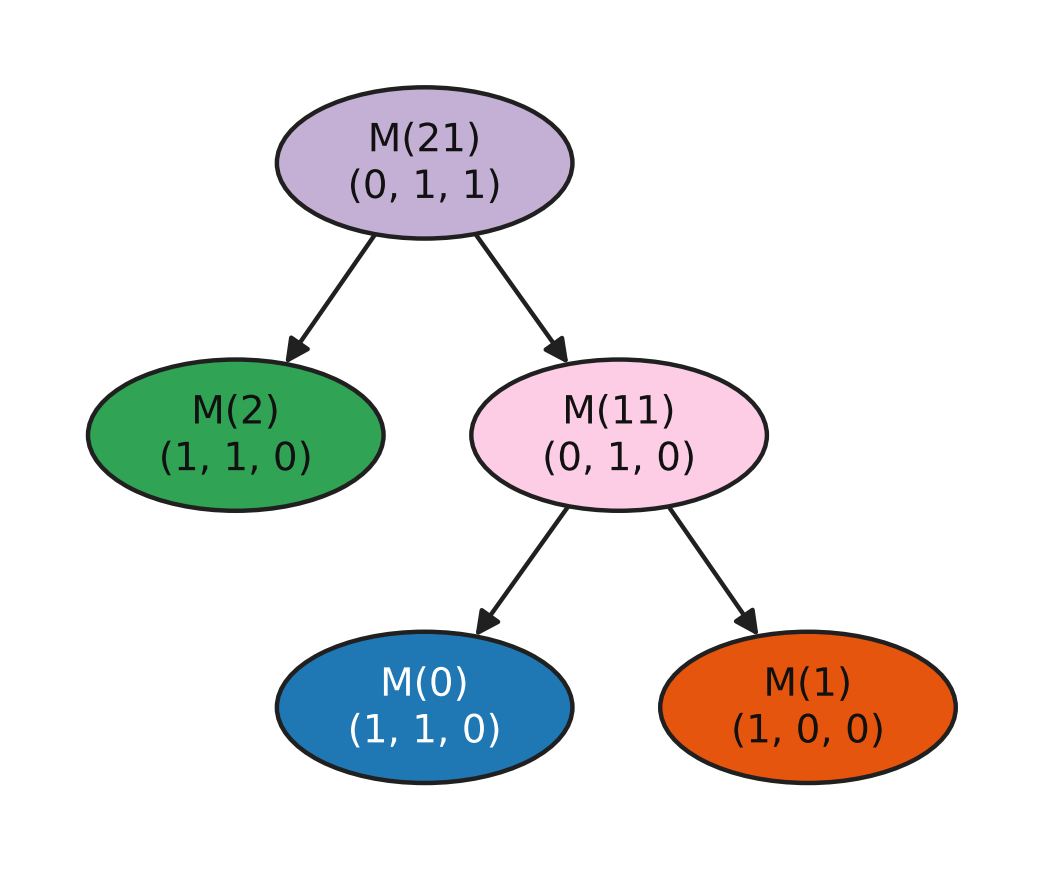

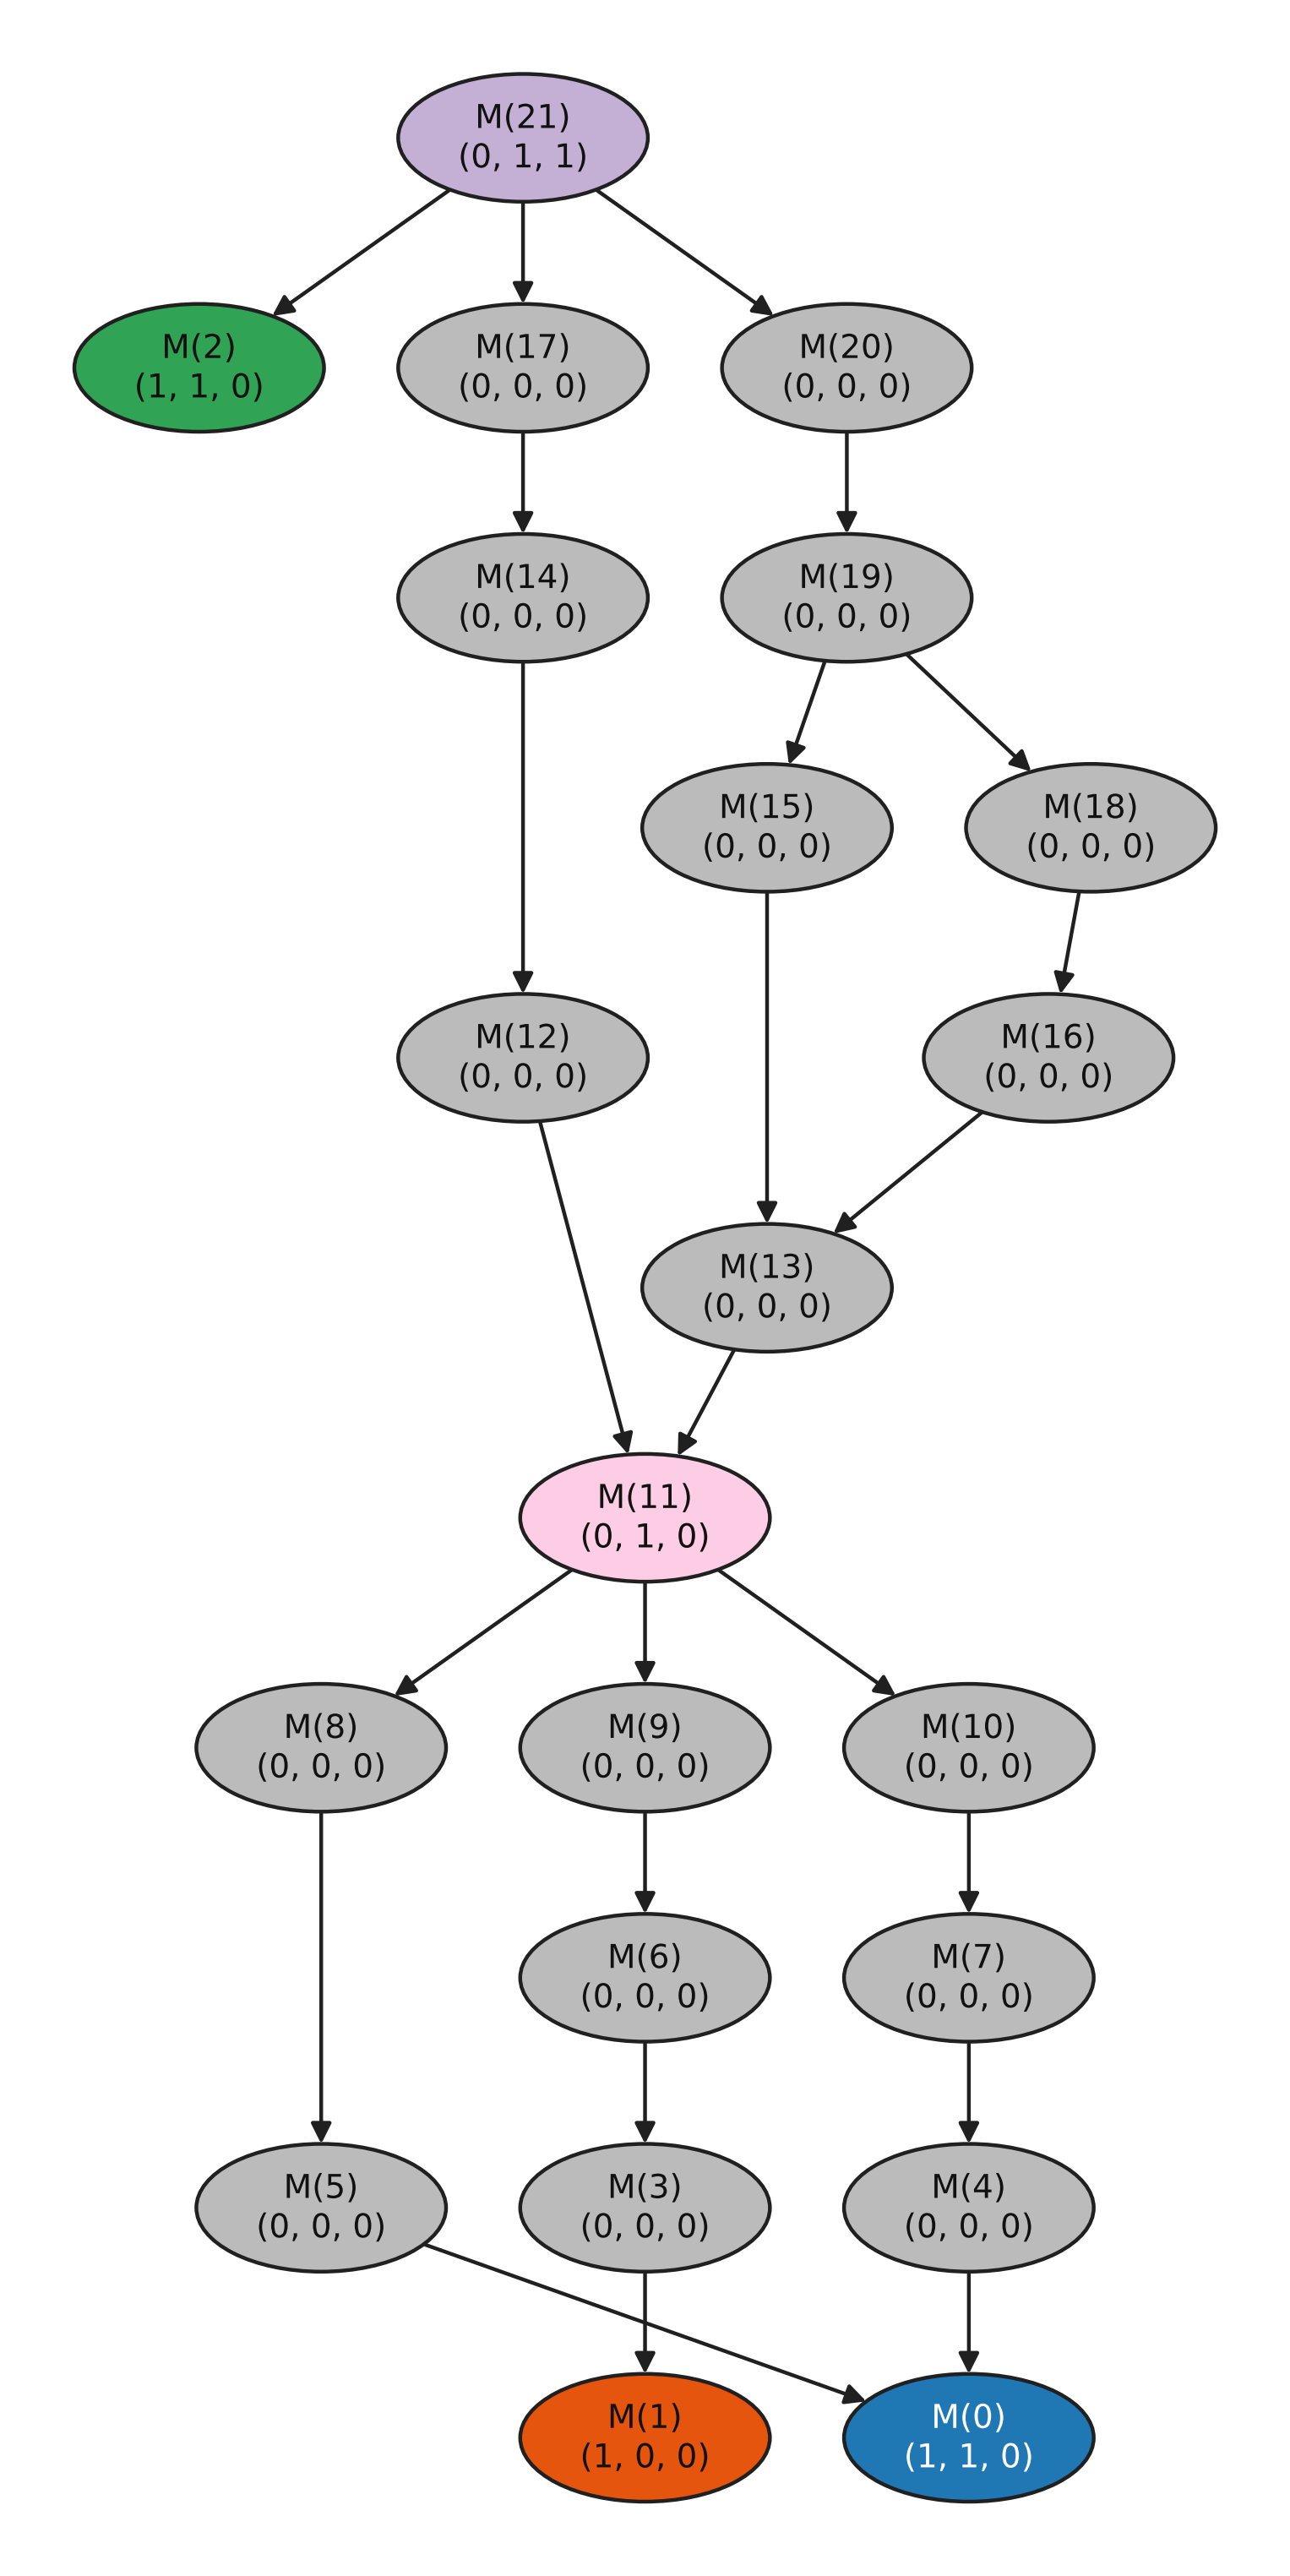

In [8]:
for panel in ["nontrivial-graph", "graph"]:
    display(Image(f"{stem}-{panel}.png", width=420))

## Attractor lattice

The lattice of down-sets of the Morse sets with nontrivial Conley index.

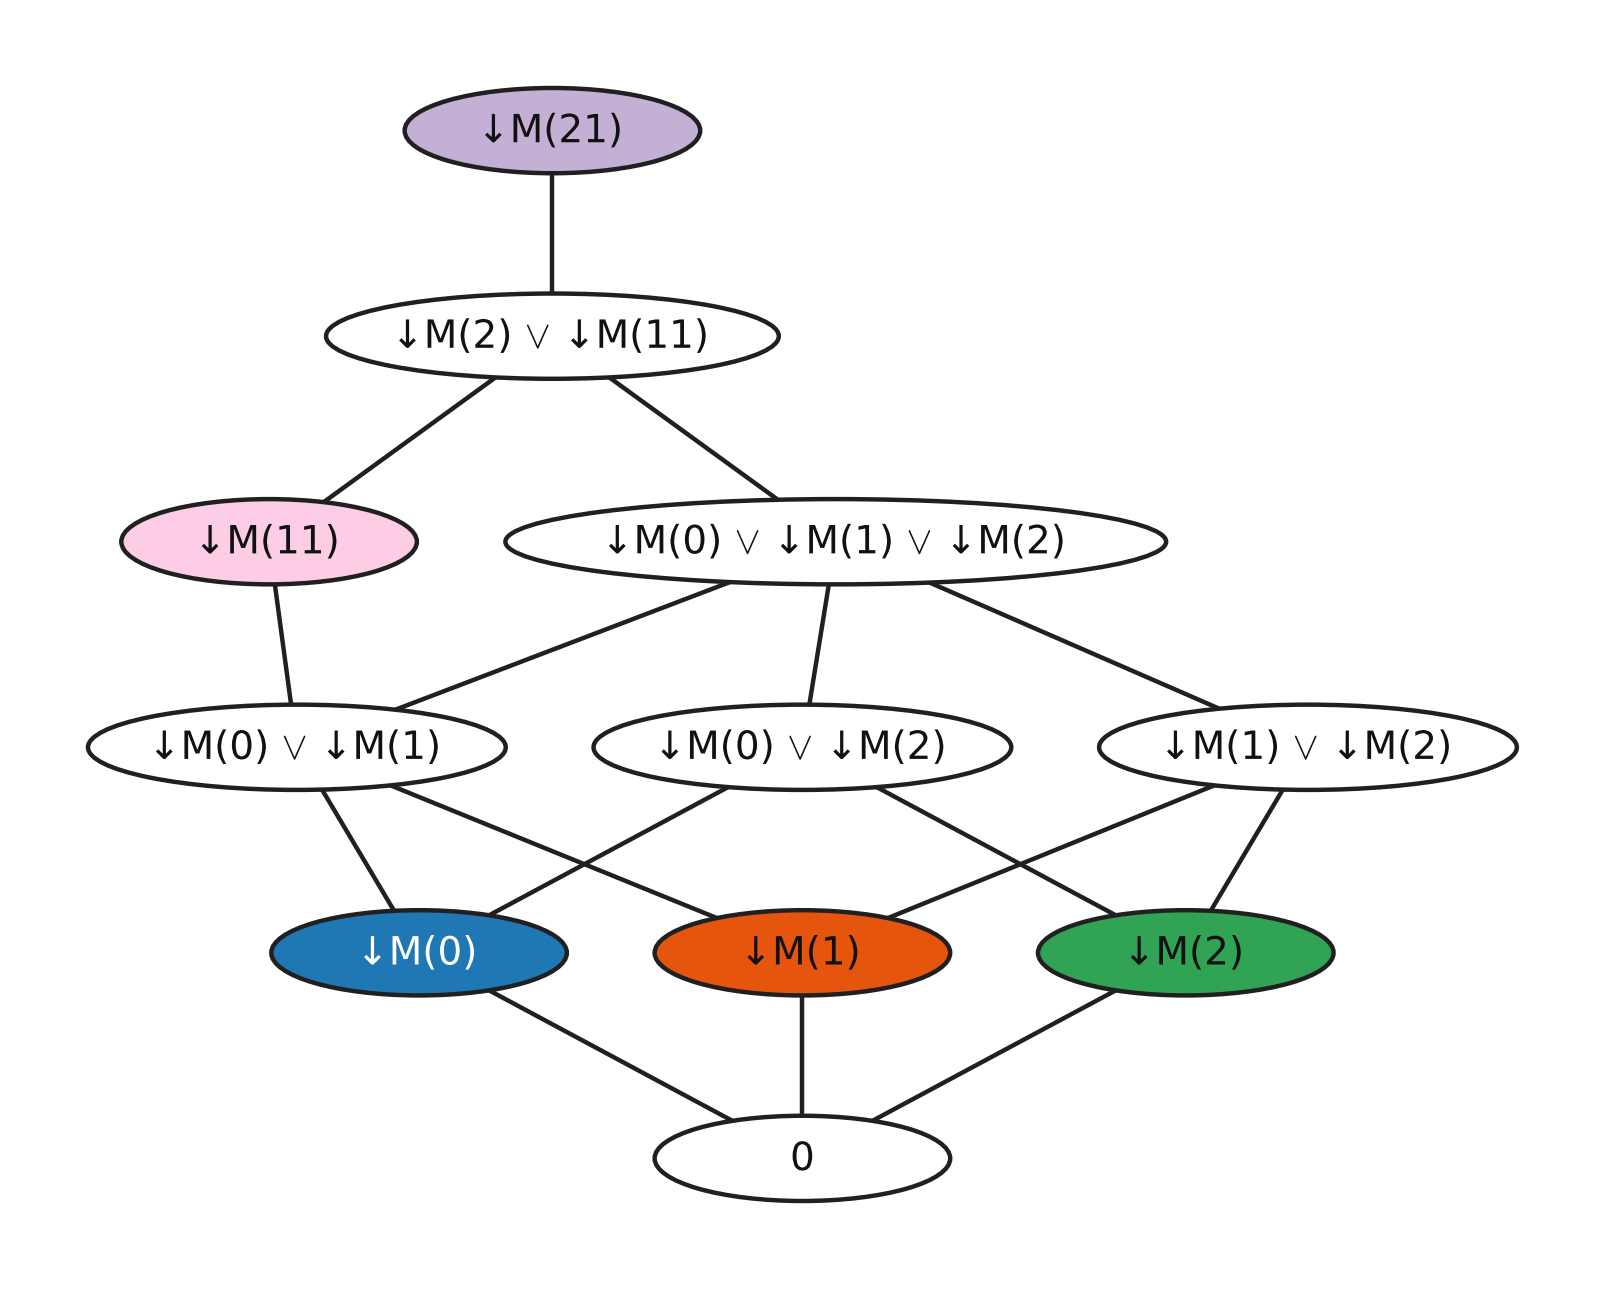

In [9]:
for panel in ["attractor-lattice"]:
    display(Image(f"{stem}-{panel}.png", width=420))